### Retail Sales Analysis
---

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [88]:
raw_df = pd.read_csv('C:/Users/nitin/OneDrive/Desktop/Data Analyst/Data/retail_store_sales.csv',sep=',')
raw_df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [89]:
summary = pd.DataFrame({
    'dtype' : raw_df.dtypes,
    'missing' : raw_df.isna().sum(),
    'missing_%' : (raw_df.isna().mean()*100).round(2),
    'unique' : raw_df.nunique()
}).sort_values('missing_%',ascending=False)
display(summary)
print(f"duplicates : {raw_df['Transaction ID'].duplicated().sum()}")

,dtype,missing,missing_%,unique
Discount Applied,object,4199,33.39,2
Item,object,1213,9.65,200
Price Per Unit,float64,609,4.84,25
Total Spent,float64,604,4.80,227
Quantity,float64,604,4.80,10
Transaction ID,object,0,0.00,12575
Customer ID,object,0,0.00,25
Category,object,0,0.00,8
Payment Method,object,0,0.00,3
Location,object,0,0.00,2


duplicates : 0


In [90]:
raw_check = raw_df.copy()
raw_check['completed'] = raw_check['Price Per Unit']*raw_check['Quantity']
completed_numeric = raw_check[raw_check[['Total Spent','Price Per Unit','Quantity']].notna().all(axis=1)]
mismatch = completed_numeric[~np.isclose(
    completed_numeric['Total Spent'],
    completed_numeric['completed'],
    atol=1e-9
)]
display(mismatch)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,completed


In [91]:
price_recover =(
    raw_df['Price Per Unit'].isna()& \
    raw_df['Quantity'].notna()& \
    raw_df['Total Spent'].notna()
)
price_recover
raw_df.loc[price_recover,'Price Per Unit'] = (raw_df.loc[price_recover,'Total Spent']/raw_df.loc[price_recover, "Quantity"])
raw_df


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [92]:
summary = pd.DataFrame({
    'dtype' : raw_df.dtypes,
    'missing' : raw_df.isna().sum(),
    'missing_%' : (raw_df.isna().mean()*100).round(2),
    'unique' : raw_df.nunique()
}).sort_values('missing_%',ascending=False)
display(summary)

,dtype,missing,missing_%,unique
Discount Applied,object,4199,33.39,2
Item,object,1213,9.65,200
Total Spent,float64,604,4.80,227
Quantity,float64,604,4.80,10
Category,object,0,0.00,8
Transaction ID,object,0,0.00,12575
Customer ID,object,0,0.00,25
Price Per Unit,float64,0,0.00,25
Payment Method,object,0,0.00,3
Location,object,0,0.00,2


In [93]:
num_df = raw_df.select_dtypes('number')

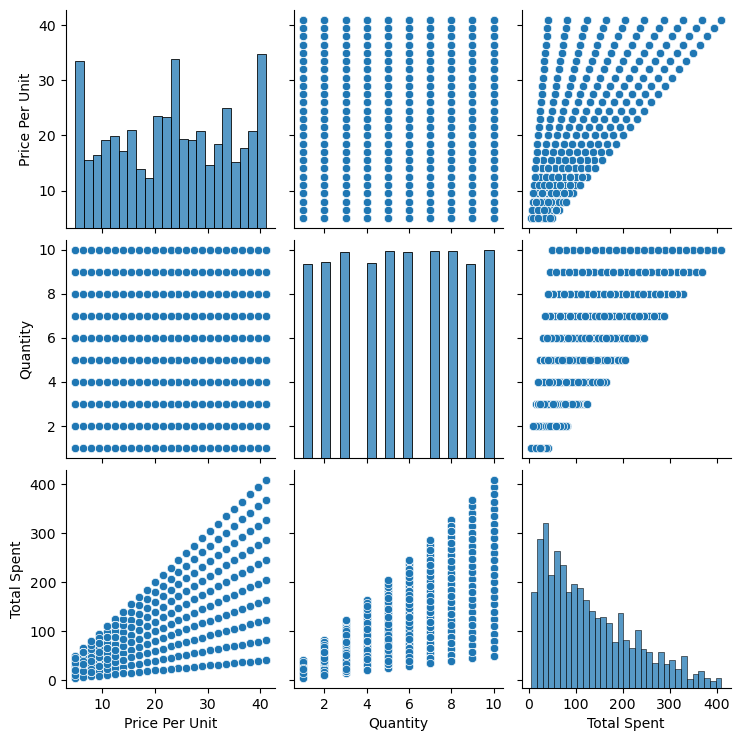

In [94]:
sns.pairplot(num_df)

In [95]:
num_df.corr()


,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000000,0.010357,0.630616
Quantity,0.010357,1.000000,0.712069
Total Spent,0.630616,0.712069,1.000000


<Axes: >

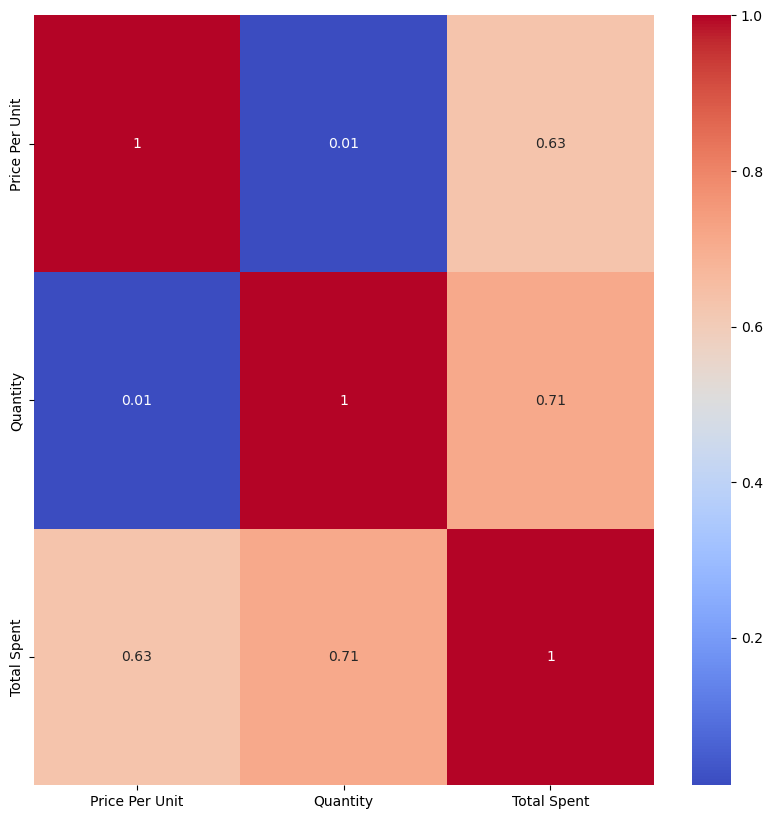

In [96]:
plt.figure(figsize=(10,10))
sns.heatmap(num_df.corr(),annot=True, \
            cmap="coolwarm"
    )

<Axes: xlabel='Total Spent', ylabel='Quantity'>

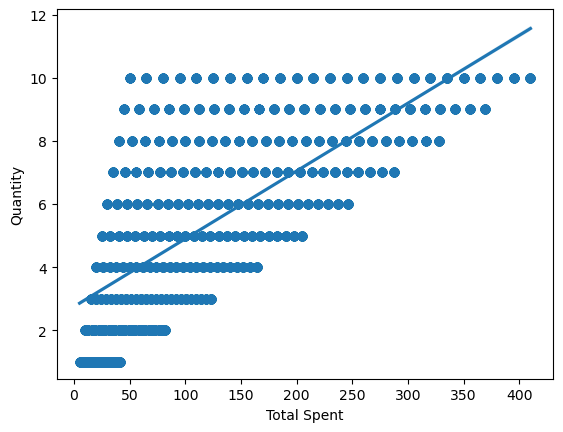

In [97]:
sns.regplot(data=num_df,x='Total Spent',y='Quantity')

In [107]:
relation = num_df.nlargest(100,'Total Spent')
relation['item'] = raw_df.loc[relation.index,'Item']
relation


,Price Per Unit,Quantity,Total Spent,item
27,41.0,10.0,410.0,Item_25_FUR
133,41.0,10.0,410.0,Item_25_FUR
339,41.0,10.0,410.0,Item_25_FOOD
869,41.0,10.0,410.0,Item_25_BEV
1060,41.0,10.0,410.0,Item_25_FUR
...,...,...,...,...
11634,39.5,10.0,395.0,Item_24_BEV
11926,39.5,10.0,395.0,Item_24_FUR
12041,39.5,10.0,395.0,Item_24_BEV
12216,39.5,10.0,395.0,Item_24_PAT


In [99]:
observe = sorted(raw_df['Price Per Unit'].dropna().unique())
price_to_number = {float(price): i+1 for i,price in enumerate(observe)}

category_codes ={
    "Beverages" : "BEV",
    "Food" : 'FOOD',
    'Milk Products' : 'MILK',
    'Butchers' : 'BUT',
    'Patisserie' : 'PAT',
    'Furniture' : 'FUR',
    'Electric household essentials' : 'EHE',
    'Computers and electric accessories' : 'CEA'
}

item_recovered =(
    raw_df['Item'].isna()& raw_df['Price Per Unit'].notna() & raw_df['Category'].isin(category_codes)
)

In [ ]:
def item(row):
    item_no = price_to_number.get(float(row['Price Per Unit']))
    codes = category_codes.get(row['Category'])
    if item_no is None or codes is None:
        return pd.Na
    return f"Item_{item_no}_{codes}"